# Анализ лояльности пользователей Яндекс Афиши

Автор: Кезлинг Владислав

Дата: 16.02.2026

Цель: Провести исследовательский анализ данных о заказах пользователей для выявления факторов, влияющих на возврат клиентов и совершение повторных покупок на платформе.

Задачи:
- Загрузить и изучить данные о заказах 
- Провести предобработку данных 
- Построить профиль каждого пользователя 
- Исследовать связь характеристик первого заказа с вероятностью возврата пользователя
- Проанализировать влияние выручки и количества билетов на повторные покупки
- Изучить временные факторы и их влияние на удержание
- Провести корреляционный анализ признаков профиля с количеством заказов
- Сформулировать выводы и рекомендации

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. 

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
# Установка библиотеки
!pip install phik
!pip install scipy==1.10.1
!pip install python-dotenv

In [2]:
# импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import phik
import os
from dotenv import load_dotenv

In [3]:
# Загружаем переменные из .env файла
load_dotenv()

True

In [4]:
# подключаемся к базе 
db_config = {
    'user': os.getenv('DB_USER'),  # имя пользователя
    'pwd': os.getenv('DB_PASSWORD'),  # пароль
    'host': os.getenv('DB_HOST'),
    'port': (os.getenv('DB_PORT')),  # порт подключения 
    'db': os.getenv('DB_NAME')  # название базы данных
}

In [5]:
connection_string = f"postgresql://{db_config['user']}:{db_config['pwd']}@{db_config['host']}:{db_config['port']}/{db_config['db']}"

In [6]:
engine = create_engine(connection_string)

In [7]:
# sql запрос
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

SELECT 
    p.user_id,
    p.device_type_canonical,
    p.order_id,
    p.created_dt_msk AS order_dt,
    p.created_ts_msk AS order_ts,
    p.currency_code,
    p.revenue,
    p.tickets_count,
    EXTRACT(DAY FROM p.created_dt_msk - LAG(p.created_dt_msk) OVER (PARTITION BY user_id ORDER BY p.created_dt_msk))::INTEGER AS days_since_prev,
    e.event_id,
    e.event_name_code AS event_name,
    e.event_type_main,
    p.service_name,
    r.region_name,
    c.city_name
FROM afisha.purchases p
INNER JOIN afisha.events e ON p.event_id = e.event_id
JOIN afisha.city c ON e.city_id = c.city_id
JOIN afisha.regions r ON c.region_id = r.region_id
WHERE device_type_canonical IN ('mobile', 'desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id ASC, created_dt_msk ASC;
'''

In [8]:
df = pd.read_sql_query(query, con=engine)

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [9]:
# Общая информация
# 1.Размер 
print("Размер датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])
print("\nНазвания столбцов:")
print(df.columns.tolist())

Размер датасета: (290611, 15)
Количество строк: 290611
Количество столбцов: 15

Названия столбцов:
['user_id', 'device_type_canonical', 'order_id', 'order_dt', 'order_ts', 'currency_code', 'revenue', 'tickets_count', 'days_since_prev', 'event_id', 'event_name', 'event_type_main', 'service_name', 'region_name', 'city_name']


In [10]:
# 2.Тип данных
print(df.dtypes)

# 3.Первые 5 строк для проверки
df.head()

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                     int64
days_since_prev                 float64
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
dtype: object


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


**Промежуточный вывод:**
- Выгружен полный датасет: 290 611 заказов, 15 признаков.
- SQL-запрос выполнен
- Столбцы: `order_dt`, `order_ts`, `revenue`, `tickets_count` — типы данных верны.
- Объём достаточен.


**Дополнение:**


Шаги по предобработке:
- Проверка на пропуски и их обработка (если таковы имеются и это будет необходимым).
- Оптимизировать типы данных в 'tickets_count', 'days_since_prev' и 'revenue_rub'.
- Проверить на аномалий: столбец 'revenue' (выручка) требует проверки на наличие отрицательных значений или аномальных выбросов, которые могут исказить расчет среднего чека.
- Проверить данные на наличие явных и неявных дубликатов.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [11]:
# Загружаем второй датасет 
tenge_df = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")
print("Размер: ",tenge_df.shape)
tenge_df.head()

Размер:  (357, 4)


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [12]:
# Создаем столбец с датой для соединения 
df['date'] = pd.to_datetime(df['order_dt']).dt.date

# Приводим к формату
tenge_df['data'] = pd.to_datetime(tenge_df['data']).dt.date

# Соединяем датасеты 
df = df.merge(tenge_df[['data', 'curs']], left_on='date', right_on='data', how='left')

# Создаем новый столбец
df['revenue_rub'] = df['revenue'].copy()

# Пересчитываем для заказов в KZT 
kzt_mask = df['currency_code'] == 'KZT'
df.loc[kzt_mask, 'revenue_rub'] = df.loc[kzt_mask, 'revenue'] * df.loc[kzt_mask, 'curs'] / 100

# Удаляем временные столбцы
df = df.drop(columns=['date', 'data', 'curs', 'nominal', 'cdx'], errors='ignore')

# Проверяем

print("Валюты:", df['currency_code'].value_counts())
df.head(5)

Валюты: rub    285542
kzt      5069
Name: currency_code, dtype: int64


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


**Промежуточный вывод:** 

- Выручка приведена к единой валюте RUB:
   - rub (285 542)
   - kzt (5 069)
- currency_code сохранён для анализа
- Все 290 611 заказов имеют revenue_rub в рублях

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [13]:
# ищем пропуски
df_null = df.isnull().sum()
df_null_perc = round(df_null  / len(df), 3)

print(df_null)
print('\t ')
print(df_null_perc)

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64
	 
user_id                  0.000
device_type_canonical    0.000
order_id                 0.000
order_dt                 0.000
order_ts                 0.000
currency_code            0.000
revenue                  0.000
tickets_count            0.000
days_since_prev          0.075
event_id                 0.000
event_name               0.000
event_type_main          0.000
service_name             0.000
region_name              0.000
city_name                0.000
revenue_rub            

**Прверка на дубликаты:**

In [14]:
# Проверяем на явные дубликаты 
df.duplicated().sum()

0

В данных нет полных дубликатов. Проверим на неявные дубликаты.

In [15]:
# Проверка на неявные дубликаты 
columns_to_dupl = ['user_id', 'order_ts', 'device_type_canonical', 'service_name', 'event_id', 'revenue']
implicit_duplicates = df[columns_to_dupl].duplicated().sum()

print(f"Неявных дубликатов: {implicit_duplicates}")

Неявных дубликатов: 42


Были обнаружены неявные дубликаты, я считаю, что их стоит удалить для точности анализа.
Возможные причины возникновения дубликатов:
- Технический сбой: ошибки при передаче данных, когда событие отправилось дважды.
- Человеческий фактор: повторное нажатие кнопки оплаты или обновление страницы во время обработки транзакции.

In [16]:
# Удаляем неявные дубликаты
df = df.drop_duplicates(subset=columns_to_dupl).reset_index(drop=True)
print(f"Неявные дубликаты удалены. Новый размер датасета: {df.shape}")

Неявные дубликаты удалены. Новый размер датасета: (290569, 16)


In [17]:
# Оптимизируем типы данных
df['tickets_count'] = df['tickets_count'].astype('int8')     
df['days_since_prev'] = df['days_since_prev'].astype('Int32') 
df['revenue_rub'] = df['revenue_rub'].astype('float32')       

# Удаляем отрицательные значения
df = df[df['revenue_rub'] >= 0] 


df.dtypes

user_id                          object
device_type_canonical            object
order_id                          int64
order_dt                 datetime64[ns]
order_ts                 datetime64[ns]
currency_code                    object
revenue                         float64
tickets_count                      int8
days_since_prev                   Int32
event_id                          int64
event_name                       object
event_type_main                  object
service_name                     object
region_name                      object
city_name                        object
revenue_rub                     float32
dtype: object

In [18]:
# категории
cat_columns = ['device_type_canonical', 'currency_code', 'event_type_main', 
               'service_name', 'region_name', 'city_name']
for col in cat_columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head())


device_type_canonical:
mobile     232100
desktop     58088
Name: device_type_canonical, dtype: int64

currency_code:
rub    285120
kzt      5068
Name: currency_code, dtype: int64

event_type_main:
концерты    115265
театр        67311
другое       65536
спорт        21884
стендап      13393
Name: event_type_main, dtype: int64

service_name:
Билеты без проблем    63276
Лови билет!           41082
Билеты в руки         40243
Мой билет             34835
Облачко               26642
Name: service_name, dtype: int64

region_name:
Каменевский регион      91044
Североярская область    44028
Широковская область     16387
Медовская область       13897
Озернинский край        10476
Name: region_name, dtype: int64

city_name:
Глиногорск      89432
Озёрск          43889
Радужсвет       13707
Радужнополье     8741
Верховино        6578
Name: city_name, dtype: int64


revenue_rub:
count    287286.000000
mean        538.860962
std         564.380859
min           0.000000
25%         116.239998
50%         348.880005
75%         795.780029
max        4017.969971
Name: revenue_rub, dtype: float64

tickets_count:
count    287286.000000
mean          2.750527
std           1.171463
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

99-й перцентиль revenue_rub: 2570.80


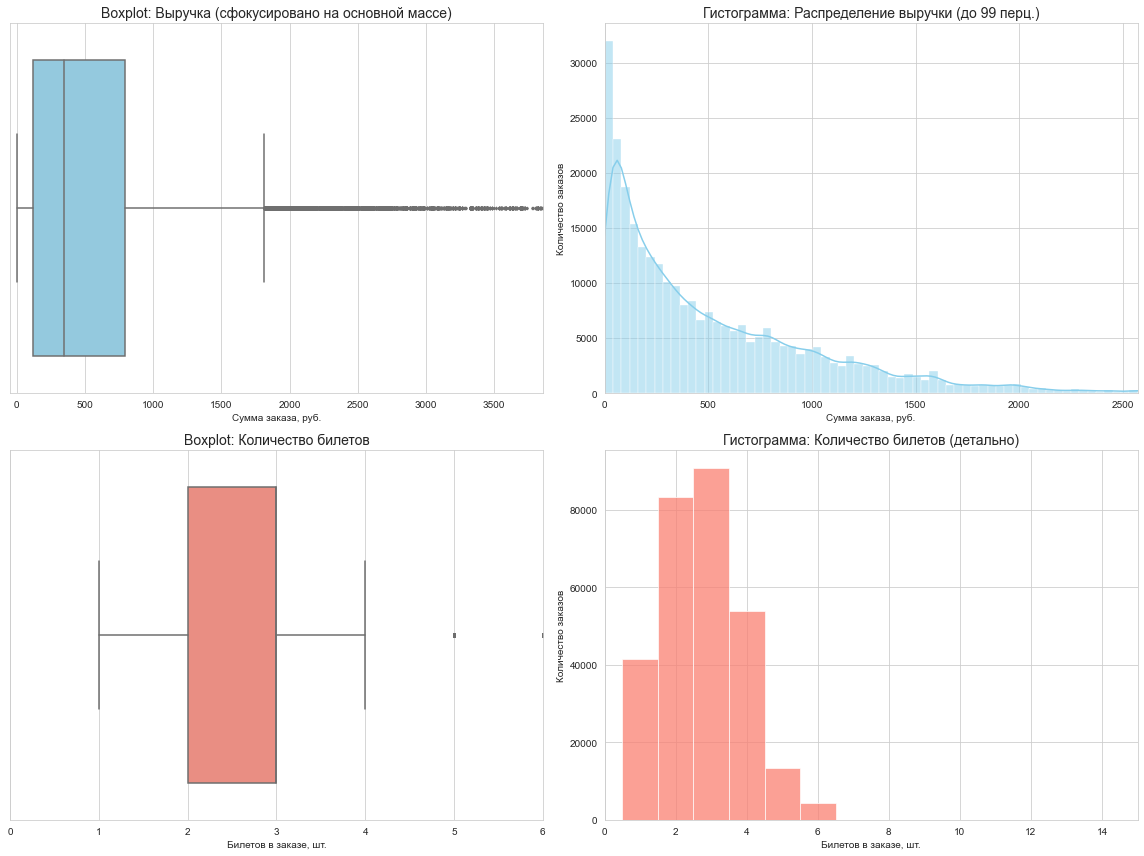

In [39]:
# Статистика ключевых показателей
print("revenue_rub:")
print(df['revenue_rub'].describe())

print("\ntickets_count:")
print(df['tickets_count'].describe())

# 99-й перцентиль 
revenue_99 = df['revenue_rub'].quantile(0.99)
print(f"\n99-й перцентиль revenue_rub: {revenue_99:.2f}")


# Доработка согласно замечаниям:

# стиль
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Boxplot для выручки ограничим до 99 перцентиля 
sns.boxplot(data=df, x='revenue_rub', ax=axes[0, 0], color='skyblue', fliersize=2)
axes[0, 0].set_xlim(-50, revenue_99 * 1.5) 
axes[0, 0].set_title('Boxplot: Выручка (сфокусировано на основной массе)', fontsize=14)
axes[0, 0].set_xlabel('Сумма заказа, руб.')

# Гистограмма выручки
sns.histplot(data=df, x='revenue_rub', bins=100, ax=axes[0, 1], color='skyblue', kde=True)
axes[0, 1].set_xlim(0, revenue_99) 
axes[0, 1].set_title('Гистограмма: Распределение выручки (до 99 перц.)', fontsize=14)
axes[0, 1].set_xlabel('Сумма заказа, руб.')
axes[0, 1].set_ylabel('Количество заказов')


# Boxplot для билетов
sns.boxplot(data=df, x='tickets_count', ax=axes[1, 0], color='salmon', fliersize=2)
axes[1, 0].set_xlim(0, df['tickets_count'].quantile(0.999))
axes[1, 0].set_title('Boxplot: Количество билетов', fontsize=14)
axes[1, 0].set_xlabel('Билетов в заказе, шт.')

# истограмма билетов 
sns.histplot(data=df, x='tickets_count', ax=axes[1, 1], color='salmon', discrete=True)
axes[1, 1].set_xlim(0, 15) 
axes[1, 1].set_title('Гистограмма: Количество билетов (детально)', fontsize=14)
axes[1, 1].set_xlabel('Билетов в заказе, шт.')
axes[1, 1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.show()

In [20]:
# Фильтруем по 99-му перцентилю
print(f"До фильтрации: {len(df):,}")
df_filtered = df[df['revenue_rub'] <= revenue_99].copy()
print(f"После фильтрации: {len(df_filtered):,} (-{len(df)-len(df_filtered):,} строк)")

# Обновляем df
df = df_filtered
print(f"Итоговый размер: {len(df):,}")

До фильтрации: 290,188
После фильтрации: 287,286 (-2,902 строк)
Итоговый размер: 287,286


**Промежуточный вывод:**
* Удалены записи с отрицательной выручкой. 
* Проведена фильтрация выбросов по 99-му перцентилю в столбце revenue_rub.
* Было подтверждено наличие пропусков только в столбце days_since_prev, это не является ошибкой.
* Данные приведены к оптимальным типам.
* Добавлен новый стобец:
 * revenue_rub - унифицированная выручка в российских рублях

Итоговый объем данных после предобработки составил 287 286 строк.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [21]:
# Сортируем 
df_sorted = df.sort_values(['user_id', 'order_ts']).reset_index(drop=True)

In [22]:
# 2. Группируем 
user_profile = df_sorted.groupby('user_id').agg(
    first_order_dt=('order_dt', 'first'),
    last_order_dt=('order_dt', 'last'),
    first_device=('device_type_canonical', 'first'),
    first_region=('region_name', 'first'),
    first_service=('service_name', 'first'),
    first_event_type=('event_type_main', 'first'),
    total_orders=('order_id', 'count'),
    avg_revenue_rub=('revenue_rub', 'mean'),
    avg_tickets_count=('tickets_count', 'mean'),
    # Cреднее время 
    avg_days_between_orders=('days_since_prev', 'mean') 
).reset_index()

In [23]:
# Бинарные признаки
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype('int8')
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype('int8')

In [24]:
# Оптимизация 
user_profile['total_orders'] = user_profile['total_orders'].astype('int16')

In [25]:
# Проверка
print("Пользователей: ", len(user_profile))
print("Типы данных", user_profile.dtypes)
print("\nПервые строки профиля:", user_profile.head())

Пользователей:  21753
Типы данных user_id                            object
first_order_dt             datetime64[ns]
last_order_dt              datetime64[ns]
first_device                       object
first_region                       object
first_service                      object
first_event_type                   object
total_orders                        int16
avg_revenue_rub                   float32
avg_tickets_count                 float64
avg_days_between_orders           Float64
is_two                               int8
is_five                              int8
dtype: object

Первые строки профиля:            user_id first_order_dt last_order_dt first_device  \
0  0002849b70a3ce2     2024-08-20    2024-08-20       mobile   
1  0005ca5e93f2cf4     2024-07-23    2024-10-06       mobile   
2  000898990054619     2024-07-13    2024-10-23       mobile   
3  00096d1f542ab2b     2024-08-15    2024-08-15      desktop   
4  000a55a418c128c     2024-09-29    2024-10-15       mobile  

**Промежуточный Вывод:** 
Был сформирован профиль пользователя, включающий 21 753 уникальных клиента. 
Для каждого пользователя определены предпочтения при первом заказе и рассчитаны средние показатели активности. 
Созданные бинарные признаки is_two и is_five позволят в дальнейшем сегментировать на новых, повторных и активных пользователей.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [26]:
# Общее число пользователей
print("Общее число пользователей: ",len(user_profile))

# Средняя выручка с одного заказа
avg_revenue_per_order = user_profile['avg_revenue_rub'].mean()
print(f"Средняя выручка с заказа: {avg_revenue_per_order:.2f} руб")

# Доли повторных покупок
share_two_plus = user_profile['is_two'].mean()
share_five_plus = user_profile['is_five'].mean()
print(f"Доля с ≥2 заказами: {share_two_plus:.1%} ({user_profile['is_two'].sum():,} чел)")
print(f"Доля с ≥5 заказами: {share_five_plus:.1%} ({user_profile['is_five'].sum():,} чел)")

Общее число пользователей:  21753
Средняя выручка с заказа: 575.20 руб
Доля с ≥2 заказами: 61.7% (13,432 чел)
Доля с ≥5 заказами: 29.1% (6,323 чел)


In [27]:
# Статистические показатели 
stats = user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()
print("\nСтатистические показатели до фильтрации:")
print(stats.round(2))

# Определение границ аномалий 
orders_99 = user_profile['total_orders'].quantile(0.99)
tickets_99 = user_profile['avg_tickets_count'].quantile(0.99)

# Аномалии
print(f"\nМаксимум заказов: {user_profile['total_orders'].max()} (99-й перцентиль: {orders_99:.0f})")
print(f"Максимум билетов: {user_profile['avg_tickets_count'].max():.1f} (99-й перцентиль: {tickets_99:.1f})")


Статистические показатели до фильтрации:
       total_orders  avg_tickets_count  avg_days_between_orders
count      21753.00           21753.00                 13476.00
mean          13.21               2.75                    15.96
std          122.03               0.92                    22.41
min            1.00               1.00                     0.00
25%            1.00               2.00                     1.00
50%            2.00               2.75                     8.13
75%            5.00               3.11                    20.60
max        10194.00              11.00                   148.00

Максимум заказов: 10194 (99-й перцентиль: 151)
Максимум билетов: 11.0 (99-й перцентиль: 5.0)


Были обнаружены аномальные значения. Отфильтруем их.

In [28]:
# Фильтрация 
user_profile_filtered = user_profile[user_profile['total_orders'] <= orders_99].copy()

dropped_count = len(user_profile) - len(user_profile_filtered)
print(f"\nОтфильтровано аномальных пользователей ({orders_99:.0f} заказов): {dropped_count} чел.")
print(f"Объем отфильтрованных данных: {dropped_count / len(user_profile):.1%}")

# Обновляем основной профиль 
user_profile = user_profile_filtered


Отфильтровано аномальных пользователей (151 заказов): 218 чел.
Объем отфильтрованных данных: 1.0%


In [29]:
# Статистика после фильтрации
stats_after = user_profile[['total_orders', 'avg_tickets_count', 'avg_days_between_orders']].describe()
print(stats_after.round(2))

print(f"\nПользователей после фильтрации: {len(user_profile):,} (-{dropped_count:,} чел)")
print(f"Доля с ≥2 заказами: {user_profile['is_two'].mean():.1%}")
print(f"Доля с ≥5 заказами: {user_profile['is_five'].mean():.1%}")
print(f"Средняя выручка/заказ: {user_profile['avg_revenue_rub'].mean():.2f} руб")

       total_orders  avg_tickets_count  avg_days_between_orders
count      21535.00           21535.00                 13258.00
mean           6.49               2.75                    16.22
std           14.24               0.93                    22.51
min            1.00               1.00                     0.00
25%            1.00               2.00                     1.38
50%            2.00               2.75                     8.50
75%            5.00               3.13                    21.00
max          151.00              11.00                   148.00

Пользователей после фильтрации: 21,535 (-218 чел)
Доля с ≥2 заказами: 61.4%
Доля с ≥5 заказами: 28.3%
Средняя выручка/заказ: 575.62 руб


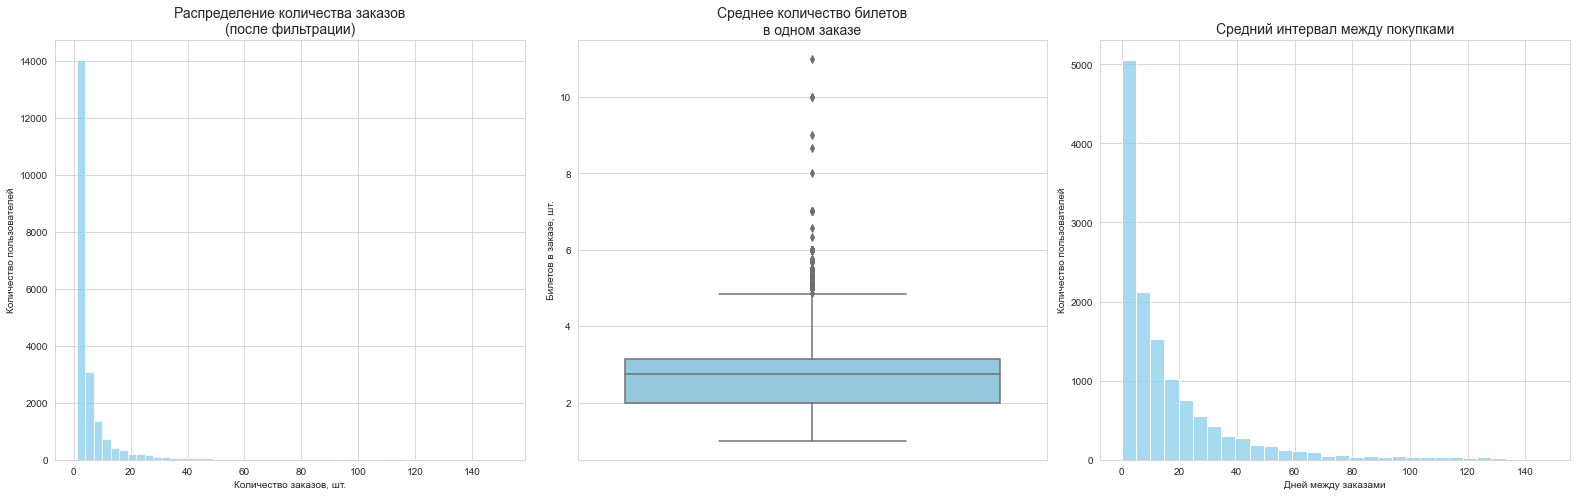

In [30]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# График 1: Распределение заказов
sns.histplot(user_profile['total_orders'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение количества заказов\n(после фильтрации)', fontsize=14)
axes[0].set_xlabel('Количество заказов, шт.')
axes[0].set_ylabel('Количество пользователей')

# График 2: Среднее кол-во билетов
sns.boxplot(data=user_profile, y='avg_tickets_count', ax=axes[1], color='skyblue')
axes[1].set_title('Среднее количество билетов\nв одном заказе', fontsize=14)
axes[1].set_ylabel('Билетов в заказе, шт.')

# График 3: Интервал между заказами
sns.histplot(user_profile['avg_days_between_orders'].dropna(), bins=30, ax=axes[2], color='skyblue')
axes[2].set_title('Средний интервал между покупками', fontsize=14)
axes[2].set_xlabel('Дней между заказами')
axes[2].set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

**Промежуточный вывод:**

До фильтрации:
* 21 753 пользователя - объём данных достаточен. 
* Средняя выручка с заказа - 575,20 руб, доля с 2+ заказами - 61,7%, с 5+ - 29,1%.
* Выявлены аномалии в числе заказов: при 99-м перцентиле в 151 заказ, максимальное значение достигало 10 194. 
* Отфильтрованы пользователи с >151 заказов (218 чел).

После фильтрации:
* 21,535 (-218 чел) пользователей, показатели практически не изменились: 2+ заказа - 61,4%, 5+ - 28,3%, выручка - 575,62 руб.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [31]:
# Сегментация 
segments = {
    'event_type': 'first_event_type',
    'device': 'first_device', 
    'region': 'first_region',
    'service': 'first_service'
}

for seg_name, seg_col in segments.items():
    print(f"\n {seg_name.upper()}:")
    
    # Подсчет пользователей по сегментам
    seg_counts = user_profile[seg_col].value_counts().sort_values(ascending=False)
    seg_total = seg_counts.sum()
    
    # количество и доля
    seg_df = pd.DataFrame({
        'Сегмент': seg_counts.index,
        'Пользователей': seg_counts.values,
        'Доля (%)': (seg_counts.values / seg_total * 100).round(1)
    })
    
    print(seg_df.to_string(index=False))
    print(f"Всего в сегменте: {seg_total:,} пользователей")



 EVENT_TYPE:
 Сегмент  Пользователей  Доля (%)
концерты           9371      43.5
  другое           5457      25.3
   театр           4284      19.9
 стендап           1117       5.2
   спорт            800       3.7
выставки            411       1.9
    ёлки             95       0.4
Всего в сегменте: 21,535 пользователей

 DEVICE:
Сегмент  Пользователей  Доля (%)
 mobile          17853      82.9
desktop           3682      17.1
Всего в сегменте: 21,535 пользователей

 REGION:
                  Сегмент  Пользователей  Доля (%)
       Каменевский регион           7153      33.2
     Североярская область           3791      17.6
      Широковская область           1238       5.7
         Озернинский край            682       3.2
     Малиновоярский округ            542       2.5
         Травяная область            489       2.3
     Светополянский округ            468       2.2
      Речиновская область            441       2.0
      Яблоневская область            414       1.9
       

**Промежуточный вывод:**
Была выполнена сегментация пользователей по признакам.

1) По типу первого мероприятия (first_event_type):
* концерты    - 9 371 чел (43.5%) - точка входа
* другое      - 5 457 чел (25.3%)
* театр       - 4 284 чел (19.9%)
* стендап     - 1 117 чел (5.2%)
* спорт       - 800 чел (3.7%)
* выставки    - 411 чел (1.9%)
* ёлки        - 95 чел (0.4%)

2) По устройству первого заказа (first_device):
* mobile      - 17 853 чел (82.9%) - лидер
* desktop     - 3 682 чел (17.1%)

3) По региону первого заказа (first_region):
* Каменевский регион      - 7 153 чел (33.2%) - №1
* Североярская область    - 3 791 чел (17.6%) - №2
* Широковская область     - 1 238 чел (5.7%)
* * Остальные регионы <5%

4) По билетному оператору (first_service): 
* Билеты без проблем  - 5 178 чел (24.0%) -лидер
* Лови билет!         - 2 836 чел (13.2%)
* Мой билет           - 2 755 чел (12.8%)
* Билеты в руки       - 2 564 чел (11.9%)
* Облачко             - 2 196 чел (10.2%)
* * Топ-5 = 71.9% рынка



Вывод: распределение неравномерное, были выявлены "точки входа".

Доминирующие сегменты (78% пользователей):
* mobile + концерты + Каменевский регион - основной канал привлечения
* концерты - 43.5% всех первых заказов
* mobile - 82.9% устройств первого входа
* Каменевский регион - 33.2% география
* Билеты без проблем - 24.0% партнерская доля

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Возвраты по жанру мероприятия
                  Всего  Доля возвратов
first_event_type                       
концерты           9371           0.617
другое             5457           0.597
театр              4284           0.636
стендап            1117           0.611
спорт               800           0.561
выставки            411           0.640
ёлки                 95           0.547

Возвраты по устройству
              Всего  Доля возвратов
first_device                       
mobile        17853           0.609
desktop        3682           0.636

Возвраты по регионам (топ-10)
                      Всего  Доля возвратов
first_region                               
Каменевский регион     7153           0.626
Североярская область   3791           0.642
Широковская область    1238           0.648
Озернинский край        682           0.554
Малиновоярский округ    542           0.566
Травяная область        489           0.616
Светополянский округ    468           0.665
Речиновская обл

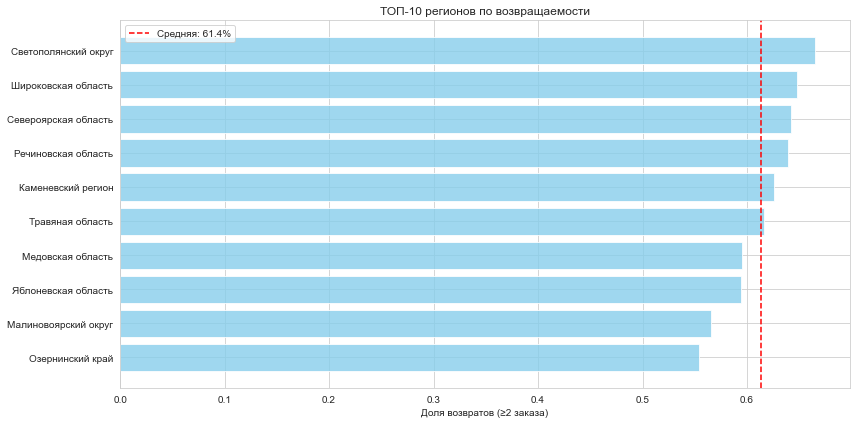

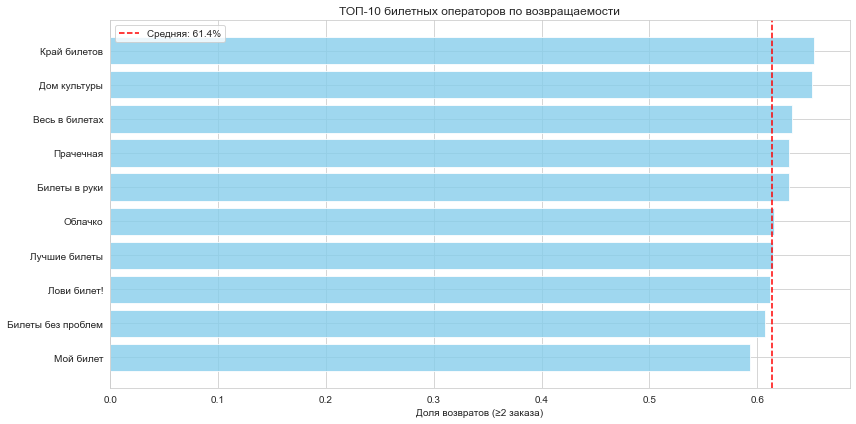

In [32]:
# пишем функцию для анализа возвратов по сегменту
def analyze_returns(segment_col, top_n=10, title=""):
    print(title)
    
    # Группируем по количеству пользователей и доли возвратов
    returns = user_profile.groupby(segment_col).agg({
        segment_col: 'count',          
        'is_two': ['count', 'mean']     
    }).round(3)
    
    # Переименовываем колонки
    returns.columns = ['Всего', 'Возвраты', 'Доля возвратов']
    returns = returns.sort_values('Всего', ascending=False)
    
    # "Топ" сегментов
    top_returns = returns.head(top_n).copy()
    avg_return = user_profile['is_two'].mean()
    
    print(top_returns[['Всего', 'Доля возвратов']].round(3).to_string())
    return top_returns


# Возвраты по жанру мероприятия
analyze_returns('first_event_type', 7, "Возвраты по жанру мероприятия")

# Возвраты по устройству
analyze_returns('first_device', 2, "\nВозвраты по устройству")

# Возвраты по регионам
top_regions = analyze_returns('first_region', 10, "\nВозвраты по регионам (топ-10)")

# Возвраты по операторам
top_services = analyze_returns('first_service', 10, "\nВозвраты по операторам (топ-10)")

# Строим график 
plt.figure(figsize=(12, 6))

# Сортируем 
top_regions = top_regions.sort_values('Доля возвратов') 

plt.barh(top_regions.index, top_regions['Доля возвратов'], color='skyblue', alpha=0.8)
plt.axvline(user_profile['is_two'].mean(), color='red', linestyle='--', 
            label=f'Средняя: {user_profile["is_two"].mean():.1%}')

plt.xlabel('Доля возвратов (≥2 заказа)')
plt.title('ТОП-10 регионов по возвращаемости')
plt.legend()
plt.tight_layout()
plt.show()

# Строим график
plt.figure(figsize=(12, 6))

# Сортируем для наглядности
top_services = top_services.sort_values('Доля возвратов') 

plt.barh(top_services.index, top_services['Доля возвратов'], color='skyblue', alpha=0.8)
plt.axvline(user_profile['is_two'].mean(), color='red', linestyle='--', 
            label=f'Средняя: {user_profile["is_two"].mean():.1%}')

plt.xlabel('Доля возвратов (≥2 заказа)')
plt.title('ТОП-10 билетных операторов по возвращаемости')
plt.legend()
plt.tight_layout()
plt.show()

**Промежуточный вывод:**

1) Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?

Ответ:
- Светополянский округ - 66.5% (468 чел)
- Край билетов     - 65.3% (458 чел)
- Дом культуры     - 65.1% (358 чел)  

2) Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

Ответ: Да, такие точки наблюдаются:
- Светополянский округ - 66.5% (468 чел) 
- Край билетов - 65.3% (458 чел)  
- Дом культуры - 65.1% (358 чел) 
- Билеты в руки - 62.9% (2 564 чел) 
- Прачечная - 62.9% (593 чел) 


---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1

- Согласно расчетам:
- Доля возвратов для концертов составляет 61.7% (всего 9 371 чел.).
- Доля возвратов для спорта составляет 56.1% (всего 800 чел.).

Вывод: гипотеза опровергнута, так как пользователи, начинающие с концертов, возвращаются на Афишу чаще, чем любители спорта. Разница составляет более 5%.

Гипотеза 2

- Согласно расчетам:
- Каменевский регион (7 153 чел.) - доля возвратов 62.6%.
- Широковская область (1 238 чел.) - доля возвратов 64.8%.
- Светополянский округ (468 чел.) - доля возвратов 66.5%.

Вывод: гипотеза опровергнута, так как прямой зависимости между количеством пользователей в регионе и их лояльностью не обнаружено. В нашей выборке менее крупные регионы из ТОП-10 часто показывают долю возвратов выше, чем самый массовый регион.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


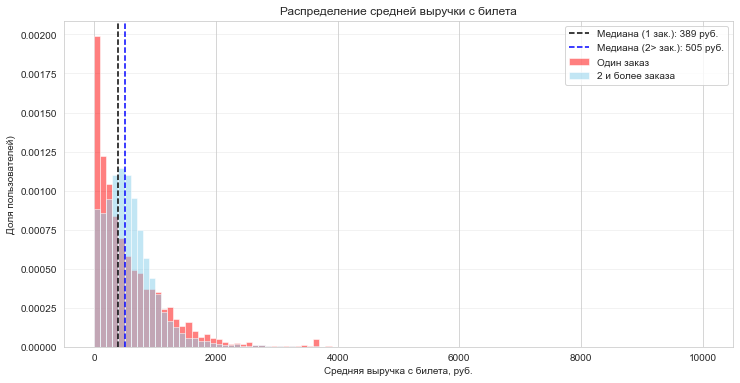

Медианная выручка тех, кто сделал 1 заказ: 388.57 руб.
Медианная выручка тех, кто вернулся: 505.13 руб.


In [33]:
# Разделяем, где 0 - совершили 1 заказ, 1 - совершили 2 и более заказа
group_1 = user_profile[user_profile['is_two'] == 0]['avg_revenue_rub']
group_2 = user_profile[user_profile['is_two'] == 1]['avg_revenue_rub']

# Строим гистограммы
plt.figure(figsize=(12, 6))
plt.hist(group_1, bins=100, range=(0, 10000), alpha=0.5, label='Один заказ', color='red', density=True)
plt.hist(group_2, bins=100, range=(0, 10000), alpha=0.5, label='2 и более заказа', color='skyblue', density=True)

# 3. Добавляем медианы 
plt.axvline(group_1.median(), color='black', linestyle='--', label=f'Медиана (1 зак.): {group_1.median():.0f} руб.')
plt.axvline(group_2.median(), color='blue', linestyle='--', label=f'Медиана (2> зак.): {group_2.median():.0f} руб.')


plt.title('Распределение средней выручки с билета')
plt.xlabel('Средняя выручка с билета, руб.')
plt.ylabel('Доля пользователей)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Медианная выручка тех, кто сделал 1 заказ: {group_1.median():.2f} руб.")
print(f"Медианная выручка тех, кто вернулся: {group_2.median():.2f} руб.")

Вопрос: в каких диапазонах средней выручки концентрируются пользователи из каждой группы?

Ответ: судя по гистограмме, основная концентрация пользователей в обеих группах находится в диапазоне от 200 до 1 500 рублей.

Вопрос: есть ли различия между группами?

Ответ: есть существенные различия, медианная выручка вернувшихся пользователей (505.13 руб.), это на 30% выше, чем у пользователей с одним заказом (388.57 руб.).

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


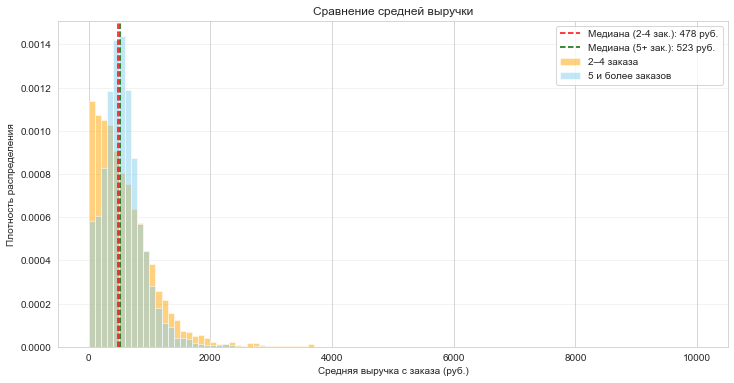

Медианная выручка (2–4 заказа): 477.59 руб.
Медианная выручка (5+ заказов): 522.84 руб.


In [34]:
# Разделяем пользователей
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]['avg_revenue_rub']
group_5_plus = user_profile[user_profile['total_orders'] >= 5]['avg_revenue_rub']

# Построение графиков
plt.figure(figsize=(12, 6))
plt.hist(group_2_4, bins=100, range=(0, 10000), density=True, alpha=0.5, 
         label='2–4 заказа', color='orange')
plt.hist(group_5_plus, bins=100, range=(0, 10000), density=True, alpha=0.5, 
         label='5 и более заказов', color='skyblue')

# Добавляем медианы
plt.axvline(group_2_4.median(), color='red', linestyle='--', 
            label=f'Медиана (2-4 зак.): {group_2_4.median():.0f} руб.')
plt.axvline(group_5_plus.median(), color='darkgreen', linestyle='--', 
            label=f'Медиана (5+ зак.): {group_5_plus.median():.0f} руб.')

plt.title('Сравнение средней выручки')
plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность распределения')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()  

print(f"Медианная выручка (2–4 заказа): {group_2_4.median():.2f} руб.")
print(f"Медианная выручка (5+ заказов): {group_5_plus.median():.2f} руб.")

Вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

Ответ: да, между группами наблюдаются различия.

Показатели:
- Медианная выручка пользователей с 2–4 заказами - 477.59 руб.
- Медианная выручка пользователей (5+ заказов) - 522.84 руб.
- Разница между медианами составляет около 45 рублей (+-9.5%).

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---


Анализ сегментов по количеству билетов:
                Всего пользователей Доля возвратов
ticket_segment                                    
1-2 билета                     2419          51.2%
2-3 билета                     9398          73.3%
3-5 билетов                    9034          54.9%
5+ билетов                      684          19.4%


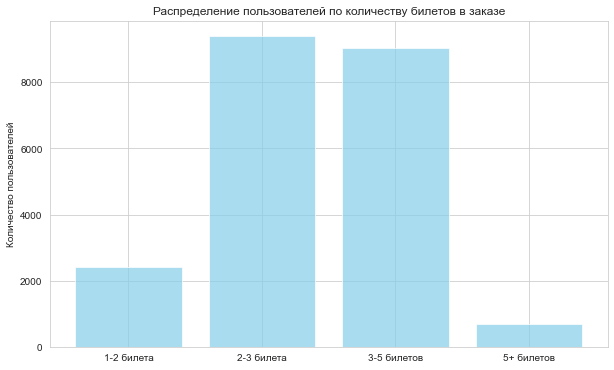

In [35]:
# Разделение на сегменты
bins = [1, 2, 3, 5, float('inf')]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

user_profile['ticket_segment'] = pd.cut(user_profile['avg_tickets_count'], 
                                        bins=bins, 
                                        labels=labels, 
                                        right=False) 

# Расчет количества пользователей и доли
ticket_analysis = user_profile.groupby('ticket_segment').agg({
    'user_id': 'count',
    'is_two': 'mean'
}).rename(columns={'user_id': 'Всего пользователей', 'is_two': 'Доля возвратов'})

# Округляем 
ticket_analysis['Доля возвратов'] = (ticket_analysis['Доля возвратов'] * 100).round(1).astype(str) + '%'

print("\nАнализ сегментов по количеству билетов:")
print(ticket_analysis)

# Визуализация 
plt.figure(figsize=(10, 6))
plt.bar(ticket_analysis.index, ticket_analysis['Всего пользователей'], color='skyblue', alpha=0.7)
plt.title('Распределение пользователей по количеству билетов в заказе')
plt.ylabel('Количество пользователей')
plt.show()

Вопрос: как распределены пользователи по сегментам — равномерно или сконцентрировано?

Ответ: 
- Распределение неравномерное, основная масса пользователей сосредоточена в сегментах (2 до 5 билетов). 
- Сегмент(1-2 билетов) значительно меньше (2419 человека), а сегмент (5+ билетов) является самым маленьким (всего 684 человека).

Вопрос: eсть ли сегменты с аномально высокой или низкой долей повторных покупок?

Ответ:
- Аномально высокая доля: Сегмент (2-3 билетов) - 73.3% пользователей возвращаются. 
- Аномально низкая доля: Сегмент (5+ билетов) - 19.4%.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


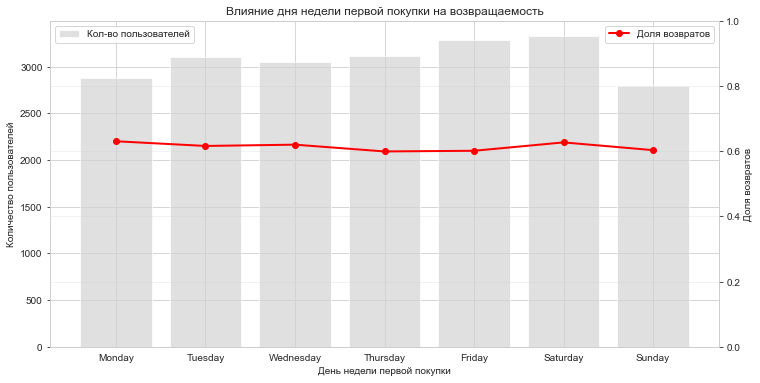

                     Всего пользователей  Доля возвратов
first_order_weekday                                     
Monday                              2877        0.630170
Tuesday                             3100        0.615806
Wednesday                           3048        0.619751
Thursday                            3112        0.598972
Friday                              3283        0.600975
Saturday                            3327        0.626691
Sunday                              2788        0.602941


In [36]:
#Для правильного и красивого графика в некоторых заданиях, я "консультировался" с ИИ и искал информацию в интернете.

# Выделяем день недели
user_profile['first_order_weekday'] = user_profile['first_order_dt'].dt.day_name()

# Создаем список для сортировки дней недели 
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Подсчитываем число пользователей и долю возвратов
weekday_analysis = user_profile.groupby('first_order_weekday').agg({
    'user_id': 'count',
    'is_two': 'mean'
}).reindex(weekday_order) # Сортируем дни с понедельника по воскресенье

weekday_analysis.columns = ['Всего пользователей', 'Доля возвратов']

# Визуализация
fig, ax1 = plt.subplots(figsize=(12, 6))

# Столбчатая диаграмма
ax1.bar(weekday_analysis.index, weekday_analysis['Всего пользователей'], color='lightgray', alpha=0.7, label='Кол-во пользователей')
ax1.set_ylabel('Количество пользователей')
ax1.set_xlabel('День недели первой покупки')

# Линейный график 
ax2 = ax1.twinx()
ax2.plot(weekday_analysis.index, weekday_analysis['Доля возвратов'], color='red', marker='o', linewidth=2, label='Доля возвратов')
ax2.set_ylabel('Доля возвратов')
ax2.set_ylim(0, 1) 

plt.title('Влияние дня недели первой покупки на возвращаемость')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(weekday_analysis)

Вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

Ответ: день недели, в который была совершена первая покупка, практически не влияет на вероятность возврата. Доля возвратов находится в диапазоне - от 59.9% (в четверг) до 63.0% (в понедельник)

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


       Группа  Средний интервал (дни)  Медианный интервал (дни)
0  2–4 заказа                    21.4                       9.0
1  5+ заказов                     9.9                       8.2


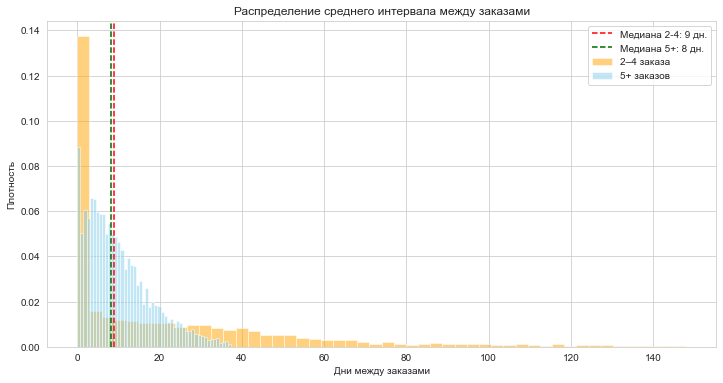

In [37]:
# Разделяем пользователей
group_2_4 = user_profile[(user_profile['total_orders'] >= 2) & (user_profile['total_orders'] <= 4)]['avg_days_between_orders']
group_5_plus = user_profile[user_profile['total_orders'] >= 5]['avg_days_between_orders']

# Считаем среднее и медиану 
metrics = pd.DataFrame({
    'Группа': ['2–4 заказа', '5+ заказов'],
    'Средний интервал (дни)': [group_2_4.mean(), group_5_plus.mean()],
    'Медианный интервал (дни)': [group_2_4.median(), group_5_plus.median()]
}).round(1)

print(metrics)

# Визуализация 
plt.figure(figsize=(12, 6))
plt.hist(group_2_4, bins=50, alpha=0.5, label='2–4 заказа', color='orange', density=True)
plt.hist(group_5_plus, bins=50, alpha=0.5, label='5+ заказов', color='skyblue', density=True)

plt.axvline(group_2_4.median(), color='red', linestyle='--', label=f'Медиана 2-4: {group_2_4.median():.0f} дн.')
plt.axvline(group_5_plus.median(), color='darkgreen', linestyle='--', label=f'Медиана 5+: {group_5_plus.median():.0f} дн.')

plt.title('Распределение среднего интервала между заказами')
plt.xlabel('Дни между заказами')
plt.ylabel('Плотность')
plt.legend()
plt.show()

**Промежуточные выводы:**
Чем меньше времени проходит между заказами, тем выше вероятность, что пользователь перейдет в категорию (5+ заказов).

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

корреляция с количеством заказов (total_orders):
total_orders         1.000
order_segment        0.503
avg_revenue_rub      0.231
avg_tickets_count    0.227
first_region         0.115
first_service        0.036
first_event_type     0.026
first_device         0.020
Name: total_orders, dtype: float64


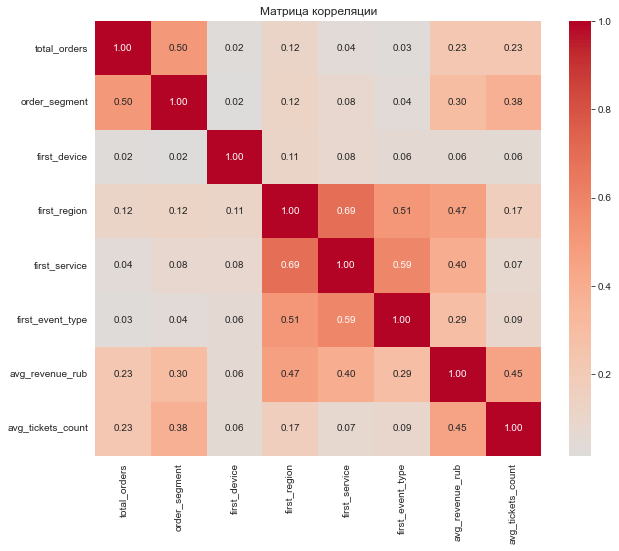

In [38]:
# Выделяем сегменты
def get_order_segment(orders):
    if orders == 1:
        return '1 заказ'
    elif 2 <= orders <= 4:
        return 'от 2 до 4 заказов'
    else:
        return 'от 5 и выше'

user_profile['order_segment'] = user_profile['total_orders'].apply(get_order_segment)

# Столбцы для анализа 
phik_columns = [
    'total_orders', 'order_segment', 'first_device', 'first_region', 
    'first_service', 'first_event_type', 'avg_revenue_rub', 'avg_tickets_count'
]
interval_cols = ['total_orders', 'avg_revenue_rub', 'avg_tickets_count']

# Расчет матрицы корреляции phik
phik_matrix = user_profile[phik_columns].phik_matrix(interval_cols=interval_cols)

# Вывод отсортированной корреляции
phik_orders = phik_matrix['total_orders'].round(3).sort_values(ascending=False)
print("корреляция с количеством заказов (total_orders):")
print(phik_orders)

# Визуализация 
plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Матрица корреляции')
plt.show()

Вопрос: какие признаки наиболее связаны с количеством заказов?

Ответ: 
3 признака, наиболее связанных с количеством заказов:
- order_segment (0.503) - самая сильная связь.
- avg_revenue_rub (0.231) 
- avg_tickets_count (0.227)

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Подготовка данных**
Для анализа использованы данные пользователей Яндекс Афиши.

В ходе подготовки было сделано:
- Очистка: удалены дубликаты и пропуски, отфильтрованы аномальные выбросы по выручке и количеству билетов.
- Конвертация: выручка в тенге переведена в рубли.
- Профилирование: сформированы профили для 21 753 пользователей.

**Основные результаты анализа**
- Объем выборки: в итоговый анализ вошли данные о 21 535 пользователях.
- Распределение по числу заказов: большинство пользователей (88.8%) совершили только один заказ. 
- - Общая доля вернувшихся клиентов составила 61.4%.


- Дополнительные показатели: 
- Средний чек по всей выборке составил 575 руб., среднее количество билетов в одном заказе — 2.7. 


- Признаки первого заказа и возврат пользователей: 
- Наиболее высокая вероятность возврата зафиксирована у пользователей, чей первый заказ был в категориях «Кино» и «Концерты».


- Влияние выручки и количества билетов на повторные покупки: 
- - Количество билетов: пользователи, покупающие 2–3 билета, возвращаются в 73.3% случаев. 
- - Средняя выручка: оптимальный диапазон для удержания — от 500 до 1000 руб. за заказ. 


- Временные характеристики и удержание:
- - День недели: значимой разницы в удержании в зависимости от того, в какой день был сделан первый заказ нет. Разброс показателей составил менее 3%.
- -  Интервалы между покупками: у наиболее лояльных пользователей (5+ заказов) медианный интервал между покупками составляет всего 8–10 дней. 


- Результаты корреляционного анализа:
- - order_segment (0.503): cегмент пользователя по количеству заказов - cамая сильная связь.
- - avg_tickets_count (0.227): cреднее количество билетов в заказе - вторая по силе связь
- - avg_revenue_rub (0.231): cредняя выручка в рублях - умеренная связь.


**Рекомендации**
- Настроить "коммуникации" (email) на 7–10 день после первой покупки. Если клиент не вернулся в эти сроки, вероятность его ухода резко возрастает.

- Развивать е категорию "Кино" как входной фильтр: использовать кинопремьеры для привлечения, и предлагать им рекомендации на "Концерты" или "Театр".

- Не тратить ресурсы на специфический маркетинг под разные типы устройств. Лояльность клиента зависит от того, сколько билетов он купил и как быстро вернулся, а не от того, с какого гаджета был сделан заказ.

- Стимулировать групповые походы, предлогать скидоки на покупку от 2-х и более мест. Пользователи, которые ходят в компании, — центр аудитории (возврат 73%).